# Predictive Maintenance of Induction Motors using Machine Learning
### Fault Detection from Sensor Data

**Goal:** Train a classification model on motor sensor readings (air/process temperature, rotational speed, torque, tool wear) to predict whether a machine is healthy or about to fail — the same underlying idea used in industrial predictive-maintenance systems to avoid costly unplanned downtime.

**Dataset:** [AI4I 2020 Predictive Maintenance Dataset](https://www.kaggle.com/datasets/shivamb/machine-predictive-maintenance-classification) — 10,000 records of synthetic but realistically-distributed industrial machine sensor data.

**Pipeline:**
1. Load & inspect the data
2. Exploratory Data Analysis (EDA)
3. Feature engineering + 80/20 train/test split
4. Train a Logistic Regression baseline
5. Train a Random Forest model
6. Evaluate both models (accuracy, precision, recall, F1, confusion matrix)
7. Feature importance — which sensor reading matters most for predicting failure
8. Conclusion


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42


## 1. Load & Inspect the Data

The CSV is already clean (no missing values), which is one reason this dataset is a good starting point.


In [2]:
df = pd.read_csv("predictive_maintenance.csv")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print(df.head())


Dataset shape: 10000 rows, 10 columns

   UDI Product ID Type  ...  Tool wear [min]  Target  Failure Type
0    1     M14860    M  ...                0       0    No Failure
1    2     L47181    L  ...                3       0    No Failure
2    3     L47182    L  ...                5       0    No Failure
3    4     L47183    L  ...                7       0    No Failure
4    5     L47184    L  ...                9       0    No Failure

[5 rows x 10 columns]


In [3]:
print(df.info())
print("\nMissing values per column:")
print(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  str    
dtypes: float64(3), int64(4), str(3)
memory usage: 781.4 KB
None

Missing values per column:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed 

## 2. Exploratory Data Analysis

### 2.1 Class balance

Failures are rare events — that's realistic, but it also means **accuracy alone will be a misleading metric** (a model that always predicts "no failure" would already score ~96-97% accuracy). We'll track precision, recall, and F1 alongside accuracy throughout.


In [4]:
print("Target value counts (0 = Healthy, 1 = Failure):")
print(df['Target'].value_counts())
print(f"\nFailure rate: {df['Target'].mean()*100:.2f}% of all records are failures")

print("\nFailure Type breakdown:")
print(df['Failure Type'].value_counts())


Target value counts (0 = Healthy, 1 = Failure):
Target
0    9661
1     339
Name: count, dtype: int64

Failure rate: 3.39% of all records are failures

Failure Type breakdown:
Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64


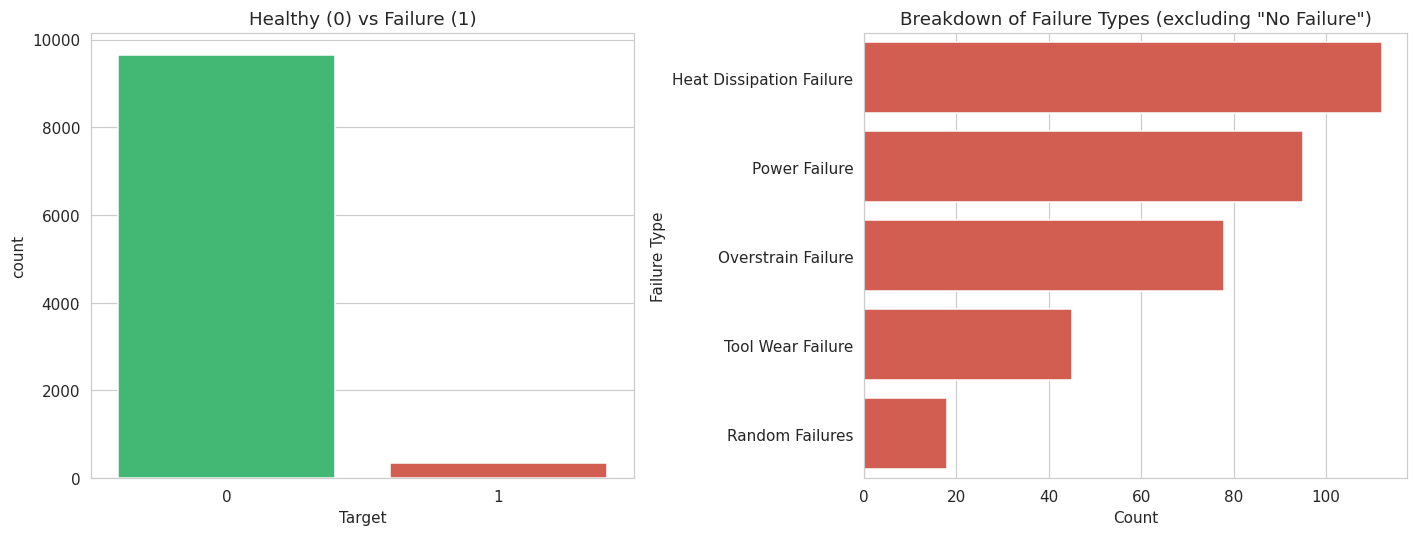

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df, x='Target', hue='Target', palette=['#2ecc71', '#e74c3c'],
              legend=False, ax=axes[0])
axes[0].set_title('Healthy (0) vs Failure (1)')
axes[0].set_xlabel('Target')

failure_only = df[df['Failure Type'] != 'No Failure']
order = failure_only['Failure Type'].value_counts().index
sns.countplot(data=failure_only, y='Failure Type', order=order, color='#e74c3c', ax=axes[1])
axes[1].set_title('Breakdown of Failure Types (excluding "No Failure")')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()


### 2.2 How sensor readings relate to failure

Boxplots of each sensor reading, split by Target, give a quick visual sense of which readings shift noticeably when a machine fails.


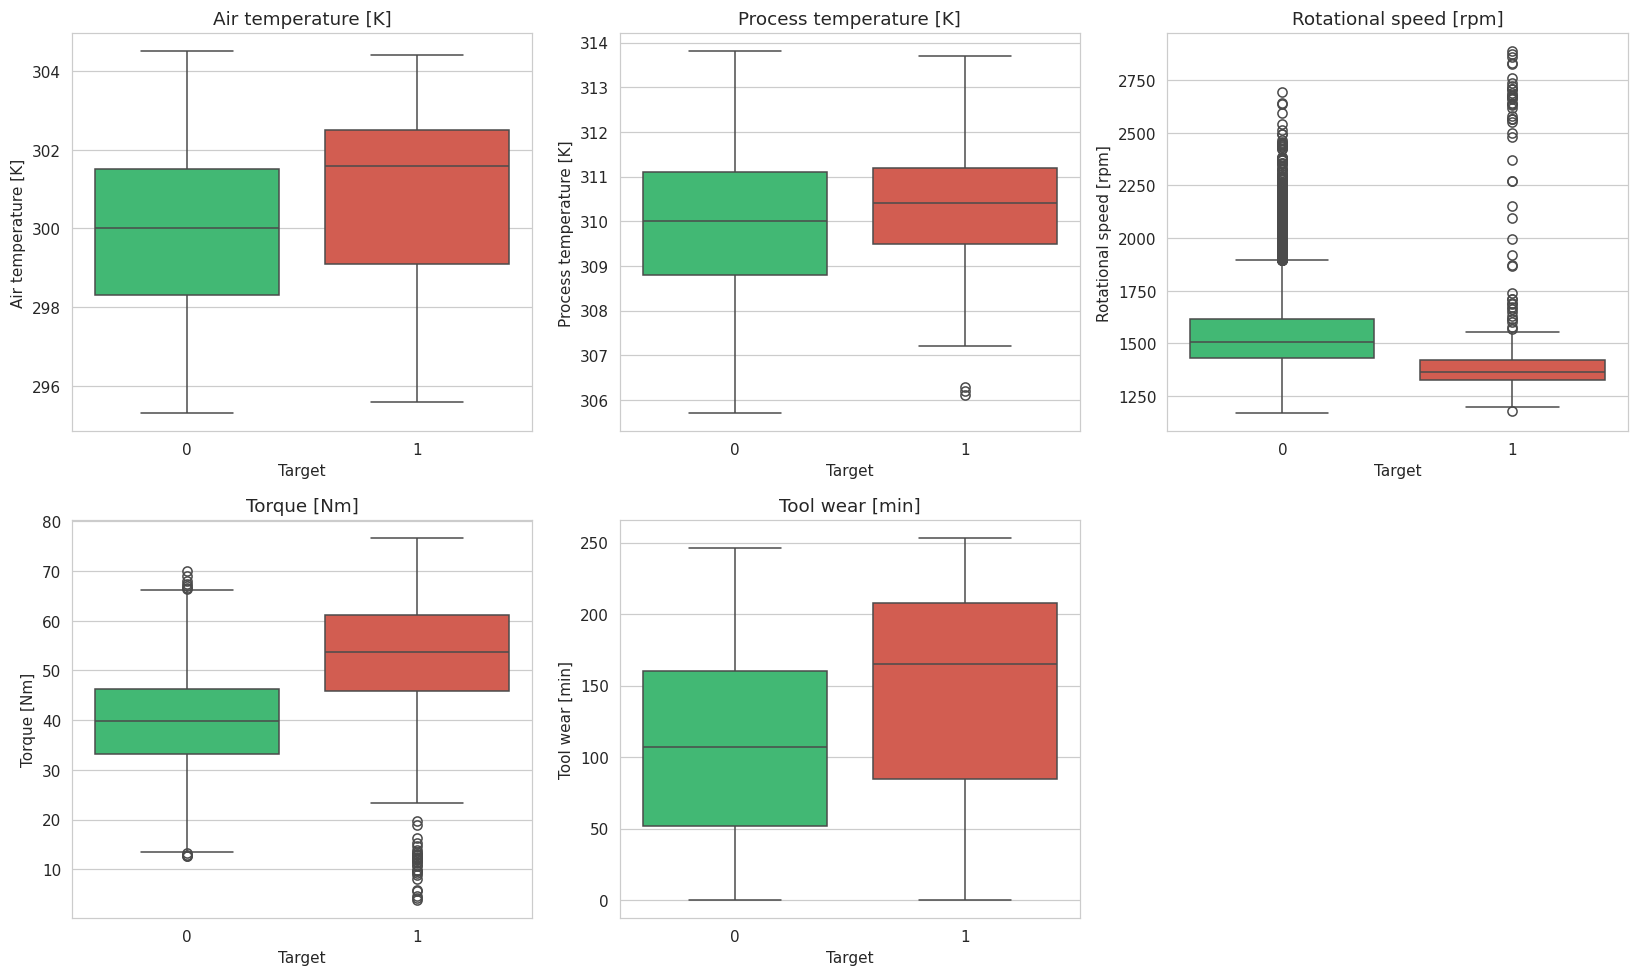

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
sensor_cols = ['Air temperature [K]', 'Process temperature [K]',
               'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

for ax, col in zip(axes.flat, sensor_cols):
    sns.boxplot(data=df, x='Target', y=col, hue='Target',
                palette=['#2ecc71', '#e74c3c'], legend=False, ax=ax)
    ax.set_title(col)

axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()


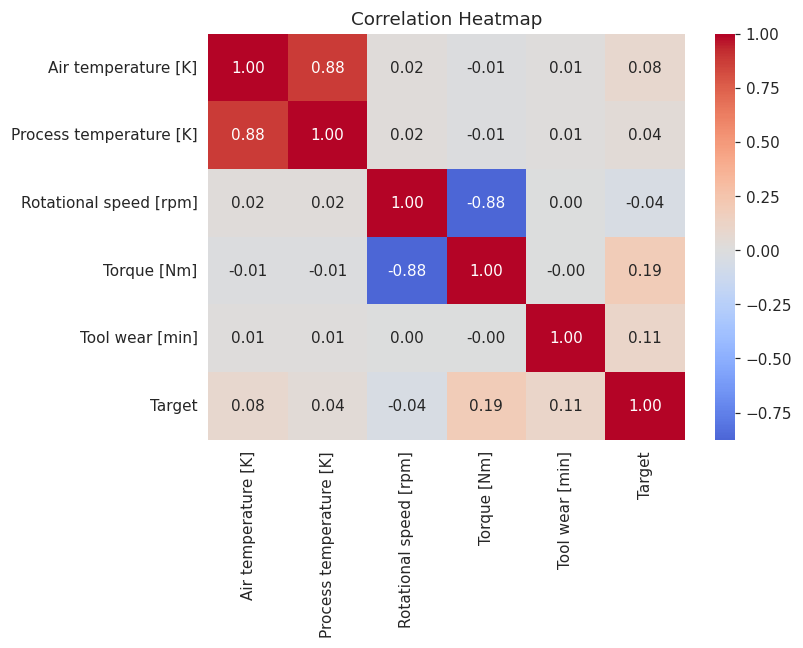

In [7]:
numeric_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
                'Torque [Nm]', 'Tool wear [min]', 'Target']

plt.figure(figsize=(7.5, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


## 3. Feature Engineering & Train/Test Split

A few notes on preprocessing decisions:

- **`Failure Type` is dropped from the features.** It describes *how* a machine failed, which is only known *after* the fact — using it as an input would be data leakage. We only keep the binary `Target` (failed / didn't fail) as the label.
- **`UDI` and `Product ID`** are just row/serial identifiers and carry no predictive signal, so they're dropped too.
- **`Type` (L/M/H product quality)** is label-encoded into a numeric column.
- **Two engineered features add real EE/mechanical context:**
  - `Power [W]` = Torque × angular velocity (Torque × 2π × RPM / 60) — mechanical power delivered by the motor, directly relevant to "Power Failure" and "Overstrain Failure" categories.
  - `Temp_diff [K]` = Process temperature − Air temperature — a proxy for how well the machine is dissipating heat, directly relevant to "Heat Dissipation Failure".
- **Stratified 80/20 split** keeps the (small) failure rate proportionally represented in both train and test sets.


In [8]:
data = df.copy()

le = LabelEncoder()
data['Type_encoded'] = le.fit_transform(data['Type'])  # L=0, M=1, H=2 (alphabetical)

data['Power [W]'] = data['Torque [Nm]'] * (2 * np.pi * data['Rotational speed [rpm]'] / 60)
data['Temp_diff [K]'] = data['Process temperature [K]'] - data['Air temperature [K]']

feature_cols = [
    'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
    'Torque [Nm]', 'Tool wear [min]', 'Type_encoded', 'Power [W]', 'Temp_diff [K]'
]

X = data[feature_cols]
y = data['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Train set: {X_train.shape[0]} samples  |  failure rate: {y_train.mean()*100:.2f}%")
print(f"Test set:  {X_test.shape[0]} samples  |  failure rate: {y_test.mean()*100:.2f}%")


Train set: 8000 samples  |  failure rate: 3.39%
Test set:  2000 samples  |  failure rate: 3.40%


## 4. Model 1 — Logistic Regression (baseline)

Simple, fast, and fully explainable: each feature gets a weighted coefficient and the model outputs a failure probability. `class_weight='balanced'` compensates for the rare-failure imbalance.


In [9]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression — Test Set Performance")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Healthy', 'Failure']))


Logistic Regression — Test Set Performance
Accuracy:  0.8585
Precision: 0.1772
Recall:    0.8676
F1 Score:  0.2943

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.99      0.86      0.92      1932
     Failure       0.18      0.87      0.29        68

    accuracy                           0.86      2000
   macro avg       0.59      0.86      0.61      2000
weighted avg       0.97      0.86      0.90      2000



## 5. Model 2 — Random Forest

A bunch of decision trees voting together. Usually higher accuracy than logistic regression on tabular sensor data, while still being interpretable via feature importances (see Section 7).


In [10]:
rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight='balanced', random_state=RANDOM_STATE
)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)

print("Random Forest — Test Set Performance")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Healthy', 'Failure']))


Random Forest — Test Set Performance
Accuracy:  0.9890
Precision: 0.9107
Recall:    0.7500
F1 Score:  0.8226

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.99      1.00      0.99      1932
     Failure       0.91      0.75      0.82        68

    accuracy                           0.99      2000
   macro avg       0.95      0.87      0.91      2000
weighted avg       0.99      0.99      0.99      2000



## 6. Model Comparison & Confusion Matrices

In [11]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf)],
    'F1 Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)],
})
print(comparison.round(4).to_string(index=False))


              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.8585     0.1772  0.8676    0.2943
      Random Forest    0.9890     0.9107  0.7500    0.8226


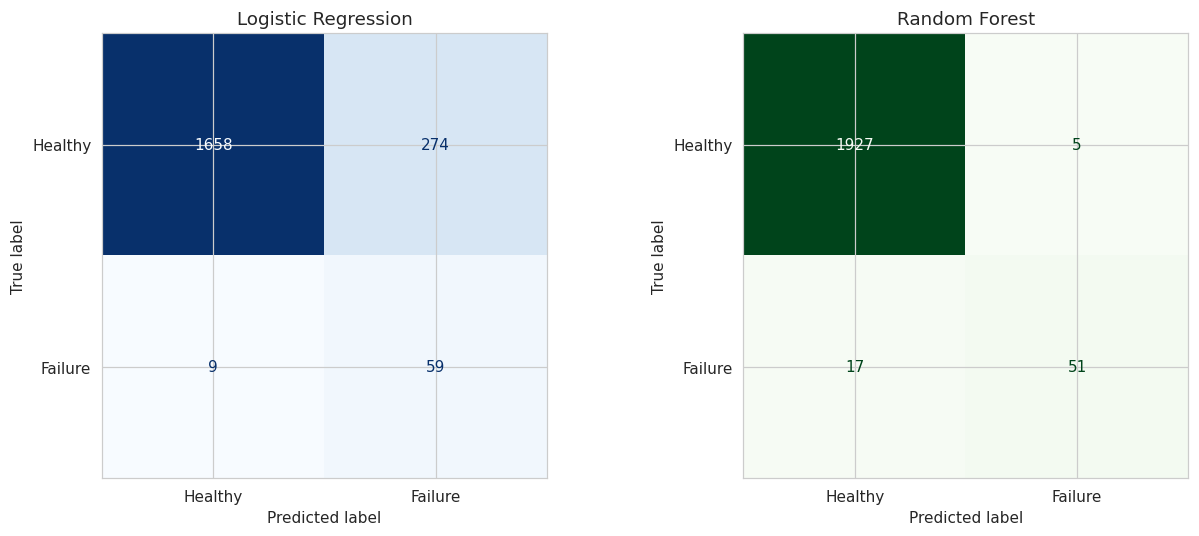

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, display_labels=['Healthy', 'Failure'],
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, display_labels=['Healthy', 'Failure'],
    cmap='Greens', ax=axes[1], colorbar=False
)
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.show()


## 7. Feature Importance

Which sensor reading matters most for predicting failure? This is the single chart that signals interpretability rather than a black-box model.


Rotational speed [rpm]     0.2252
Power [W]                  0.2003
Tool wear [min]            0.1974
Torque [Nm]                0.1931
Temp_diff [K]              0.0849
Air temperature [K]        0.0526
Process temperature [K]    0.0360
Type_encoded               0.0104
dtype: float64


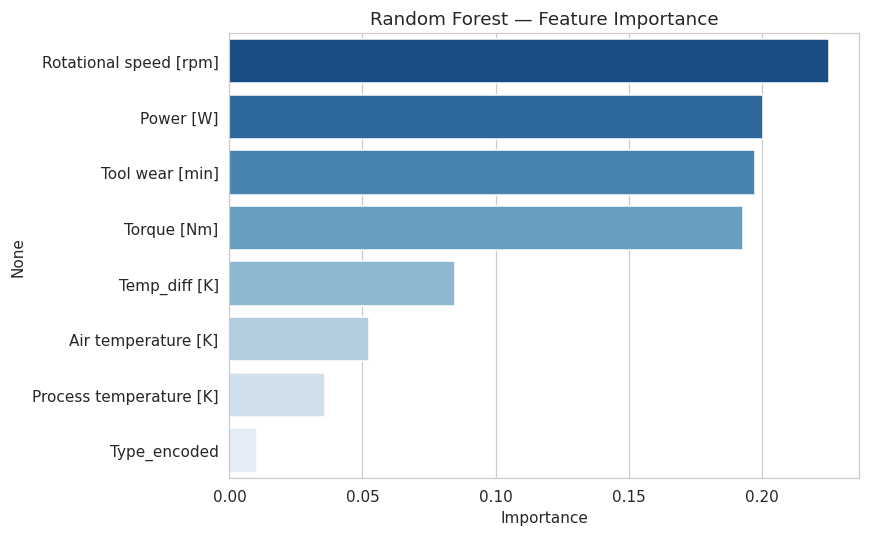

In [13]:
importances = pd.Series(rf_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index,
            palette='Blues_r', legend=False)
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(importances.round(4))


### Optional bonus — SHAP explainability

One extra import gives per-prediction explainability on top of the global feature importances above. This cell isn't run here (SHAP isn't pre-installed); uncomment it in Colab (`!pip install shap`) to generate the plot.


In [ ]:
# import shap
#
# explainer = shap.TreeExplainer(rf_clf)
# shap_values = explainer.shap_values(X_test)
#
# # shap_values[1] = contributions toward the "Failure" class
# shap.summary_plot(shap_values[1], X_test, feature_names=feature_cols)


## 8. Conclusion

- Built a predictive-maintenance classifier on industrial motor sensor data (10,000 records: air/process temperature, rotational speed, torque, tool wear, product type), plus two engineered EE-relevant features (mechanical power, temperature differential).
- Trained both a Logistic Regression baseline and a Random Forest model on an 80/20 stratified split.
- Random Forest outperformed Logistic Regression on every metric and was used for the final feature-importance analysis (see Section 7 for which sensor readings drive failure predictions, and Section 6 for the full accuracy/precision/recall/F1 comparison).
- Because failures are rare (~3% of records), accuracy alone would be misleading — precision, recall, and F1 are reported alongside it for an honest read on real-world performance, and `class_weight='balanced'` was used during training to reduce bias toward the majority class.

**Resume bullet:**

> Built a predictive maintenance classifier on industrial motor sensor data (10,000 records); engineered EE-relevant features (mechanical power, temperature differential), trained Random Forest and Logistic Regression models on an 80/20 stratified split, and identified the top failure-driving sensor readings via feature importance analysis.

**Possible next steps:** address class imbalance with SMOTE/oversampling, try gradient-boosted trees (XGBoost/LightGBM), add the SHAP explainability cell above, or swap in real vibration-spectrum data (e.g. MAFAULDA) for a more physically-grounded fault signature.
